# Data Quality Analysis for RAG System

This notebook analyzes your video data to determine if you have enough content for a quality RAG system.

**Key Questions:**
1. How long are the videos?
2. How dense is the content (sentences per minute)?
3. How many chunks do we get per video?
4. Is this enough for good RAG performance?
5. Do we need more videos?

## 1. Load Your Processed Data

In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Imports successful")

✓ Imports successful


In [8]:
# Load your raw video data
with open('../data/raw/video_aQf6Q8t1FQE.json', 'r', encoding='utf-8') as f:
    videos = json.load(f)

# Load your processed chunks
with open('../data/processed/chunks_aQf6Q8t1FQE.json', 'r', encoding='utf-8') as f:
    chunks = json.load(f)

video_id = videos["video_id"]
segments = videos["transcript"]

print(f"✓ Loaded video: {video_id}")
print(f"✓ Transcript segments: {len(segments)}")
print(f"✓ Chunks: {len(chunks)}")

✓ Loaded video: aQf6Q8t1FQE
✓ Transcript segments: 120
✓ Chunks: 10


## 2. Basic Video Statistics

In [10]:
# Ensure videos is a list of video objects
if isinstance(videos, dict):
    videos = [videos]

# Extract video statistics
video_stats = []

for video in videos:
    metadata = video.get('metadata', {})
    transcript = video.get('transcript', [])
    
    # Calculate statistics
    duration_sec = metadata.get('duration', 0) or 0
    duration_min = duration_sec / 60 if duration_sec else 0
    
    # Count transcript entries
    num_segments = len(transcript)
    
    # Calculate total words
    if transcript:
        full_text = ' '.join(entry.get('text', '') for entry in transcript)
        num_words = len(full_text.split())
        num_chars = len(full_text)
        num_sentences = sum(full_text.count(x) for x in ['.', '!', '?'])
    else:
        num_words = num_chars = num_sentences = 0
    
    video_stats.append({
        'video_id': metadata.get('video_id', video.get('video_id', '')),
        'title': metadata.get('title', ''),
        'duration_min': duration_min,
        'duration_sec': duration_sec,
        'segments': num_segments,
        'words': num_words,
        'characters': num_chars,
        'sentences': num_sentences,
        'words_per_min': (num_words / duration_min) if duration_min > 0 else 0,
        'sentences_per_min': (num_sentences / duration_min) if duration_min > 0 else 0
    })

df_videos = pd.DataFrame(video_stats)

print("\n" + "="*80)
print("VIDEO STATISTICS SUMMARY")
print("="*80)
df_videos


VIDEO STATISTICS SUMMARY


,video_id,title,duration_min,duration_sec,segments,words,characters,sentences,words_per_min,sentences_per_min
0,aQf6Q8t1FQE,An Introduction to Stress and Strain,10.016667,601,120,1378,7906,79,137.570715,7.886855


## 3. Overall Dataset Statistics

In [11]:
print("\n" + "="*80)
print("OVERALL DATASET STATISTICS")
print("="*80)

total_videos = len(df_videos)
total_duration = df_videos['duration_min'].sum()
total_words = df_videos['words'].sum()
total_sentences = df_videos['sentences'].sum()
total_chunks = len(chunks)

print(f"\n📊 Content Volume:")
print(f"  Total Videos: {total_videos}")
print(f"  Total Duration: {total_duration:.1f} minutes ({total_duration/60:.1f} hours)")
print(f"  Total Words: {total_words:,}")
print(f"  Total Sentences: {total_sentences:,}")
print(f"  Total Chunks: {total_chunks:,}")

print(f"\n📏 Averages:")
print(f"  Avg Video Duration: {df_videos['duration_min'].mean():.1f} minutes")
print(f"  Avg Words per Video: {df_videos['words'].mean():.0f}")
print(f"  Avg Sentences per Video: {df_videos['sentences'].mean():.0f}")
print(f"  Avg Chunks per Video: {total_chunks/total_videos:.1f}")

print(f"\n⚡ Content Density:")
print(f"  Avg Words per Minute: {df_videos['words_per_min'].mean():.0f}")
print(f"  Avg Sentences per Minute: {df_videos['sentences_per_min'].mean():.1f}")

print(f"\n📦 Chunk Statistics:")
chunk_sizes = [len(chunk['text']) for chunk in chunks]
print(f"  Avg Chunk Size: {np.mean(chunk_sizes):.0f} characters")
print(f"  Min Chunk Size: {np.min(chunk_sizes):.0f} characters")
print(f"  Max Chunk Size: {np.max(chunk_sizes):.0f} characters")


OVERALL DATASET STATISTICS

📊 Content Volume:
  Total Videos: 1
  Total Duration: 10.0 minutes (0.2 hours)
  Total Words: 1,378
  Total Sentences: 79
  Total Chunks: 10

📏 Averages:
  Avg Video Duration: 10.0 minutes
  Avg Words per Video: 1378
  Avg Sentences per Video: 79
  Avg Chunks per Video: 10.0

⚡ Content Density:
  Avg Words per Minute: 138
  Avg Sentences per Minute: 7.9

📦 Chunk Statistics:
  Avg Chunk Size: 915 characters
  Min Chunk Size: 445 characters
  Max Chunk Size: 999 characters


## 4. Visual Analysis

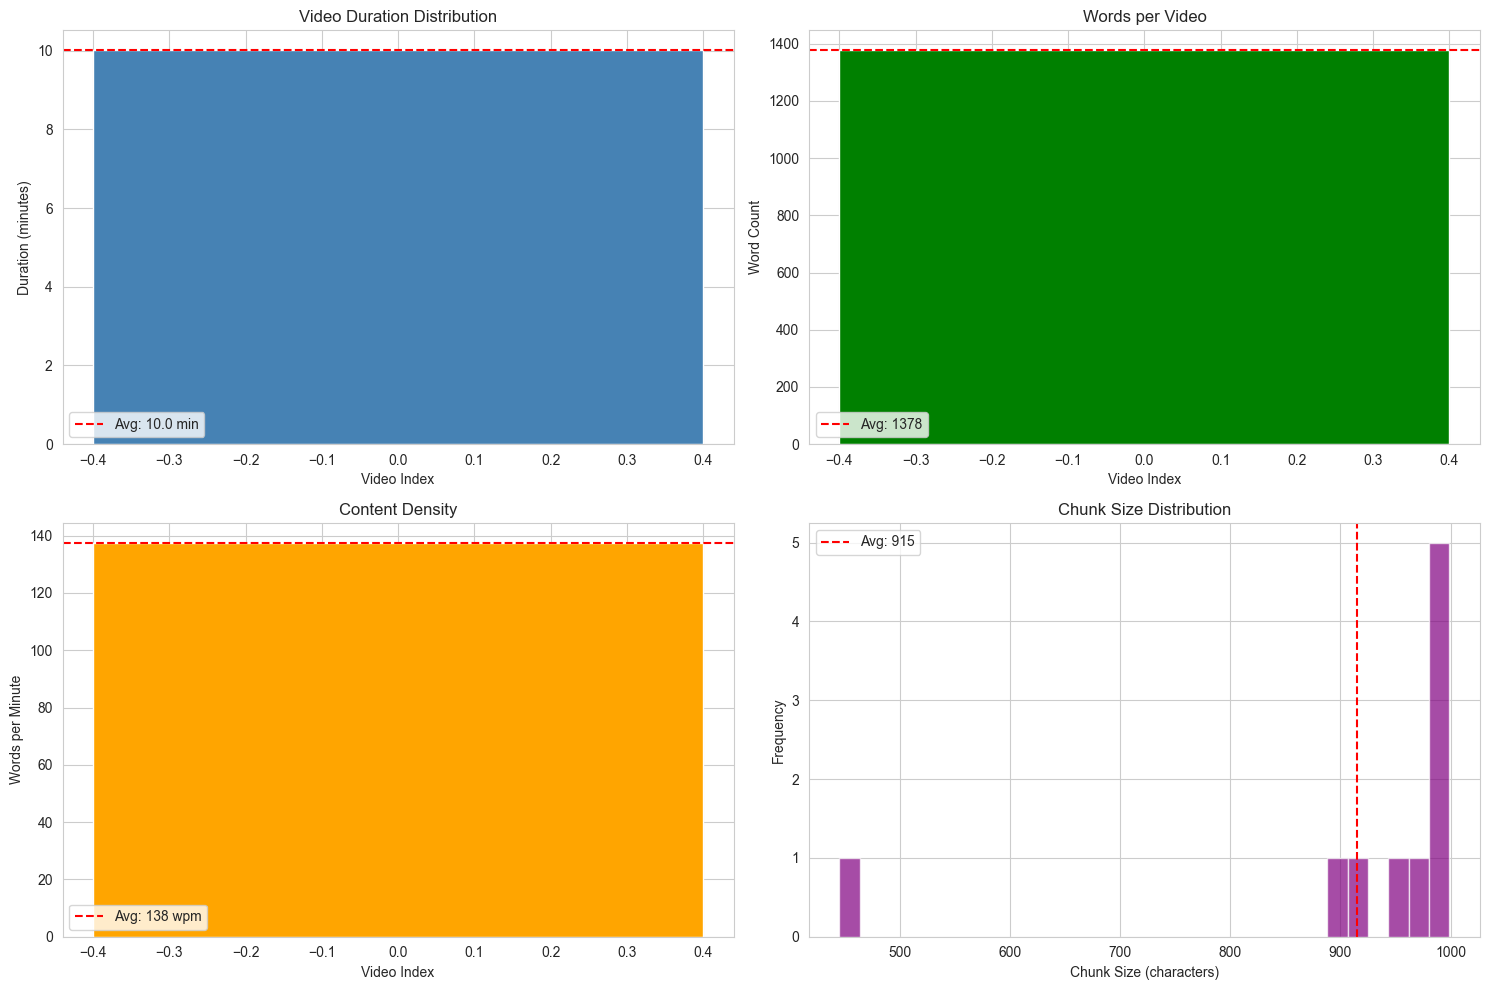

In [12]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Video Duration Distribution
axes[0, 0].bar(range(len(df_videos)), df_videos['duration_min'], color='steelblue')
axes[0, 0].set_xlabel('Video Index')
axes[0, 0].set_ylabel('Duration (minutes)')
axes[0, 0].set_title('Video Duration Distribution')
axes[0, 0].axhline(df_videos['duration_min'].mean(), color='red', 
                   linestyle='--', label=f'Avg: {df_videos["duration_min"].mean():.1f} min')
axes[0, 0].legend()

# 2. Words per Video
axes[0, 1].bar(range(len(df_videos)), df_videos['words'], color='green')
axes[0, 1].set_xlabel('Video Index')
axes[0, 1].set_ylabel('Word Count')
axes[0, 1].set_title('Words per Video')
axes[0, 1].axhline(df_videos['words'].mean(), color='red', 
                   linestyle='--', label=f'Avg: {df_videos["words"].mean():.0f}')
axes[0, 1].legend()

# 3. Content Density (Words per Minute)
axes[1, 0].bar(range(len(df_videos)), df_videos['words_per_min'], color='orange')
axes[1, 0].set_xlabel('Video Index')
axes[1, 0].set_ylabel('Words per Minute')
axes[1, 0].set_title('Content Density')
axes[1, 0].axhline(df_videos['words_per_min'].mean(), color='red', 
                   linestyle='--', label=f'Avg: {df_videos["words_per_min"].mean():.0f} wpm')
axes[1, 0].legend()

# 4. Chunk Size Distribution
axes[1, 1].hist(chunk_sizes, bins=30, color='purple', alpha=0.7)
axes[1, 1].set_xlabel('Chunk Size (characters)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Chunk Size Distribution')
axes[1, 1].axvline(np.mean(chunk_sizes), color='red', 
                   linestyle='--', label=f'Avg: {np.mean(chunk_sizes):.0f}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 5. Quality Assessment

### Industry Benchmarks for RAG Systems

In [13]:
print("\n" + "="*80)
print("RAG QUALITY ASSESSMENT")
print("="*80)

# Industry benchmarks
benchmarks = {
    'min_chunks': 50,      # Minimum chunks for basic RAG
    'good_chunks': 100,    # Good number for quality RAG
    'excellent_chunks': 200,  # Excellent coverage
    'min_words': 10000,    # Minimum total words
    'good_words': 20000,   # Good word count
    'min_chunk_size': 200, # Minimum chunk size
    'max_chunk_size': 1500, # Maximum chunk size
}

# Assess your data
print("\n📊 Your Dataset vs Benchmarks:\n")

def assess(value, min_val, good_val, name):
    if value >= good_val:
        status = "✅ EXCELLENT"
    elif value >= min_val:
        status = "🟡 GOOD"
    else:
        status = "⚠️  NEEDS MORE"
    print(f"  {name}: {value:,} {status}")
    print(f"    Benchmark: Min={min_val:,}, Good={good_val:,}")
    return value >= min_val

checks = []
checks.append(assess(total_chunks, benchmarks['min_chunks'], 
                     benchmarks['good_chunks'], "Total Chunks"))
checks.append(assess(total_words, benchmarks['min_words'], 
                     benchmarks['good_words'], "Total Words"))

avg_chunk_size = np.mean(chunk_sizes)
print(f"\n  Avg Chunk Size: {avg_chunk_size:.0f} chars", end=" ")
if benchmarks['min_chunk_size'] <= avg_chunk_size <= benchmarks['max_chunk_size']:
    print("✅ OPTIMAL")
    checks.append(True)
else:
    print("⚠️  SUBOPTIMAL")
    checks.append(False)
print(f"    Optimal Range: {benchmarks['min_chunk_size']}-{benchmarks['max_chunk_size']} chars")

# Overall assessment
print("\n" + "="*80)
if all(checks):
    print("✅ OVERALL: Your dataset is GOOD for RAG!")
    print("   You have sufficient data for a quality chatbot.")
elif sum(checks) >= 2:
    print("🟡 OVERALL: Your dataset is ACCEPTABLE for RAG")
    print("   It will work, but adding 2-3 more videos would improve quality.")
else:
    print("⚠️  OVERALL: Your dataset NEEDS MORE CONTENT")
    print("   Recommend adding 3-5 more videos for better performance.")
print("="*80)


RAG QUALITY ASSESSMENT

📊 Your Dataset vs Benchmarks:

  Total Chunks: 10 ⚠️  NEEDS MORE
    Benchmark: Min=50, Good=100
  Total Words: 1,378 ⚠️  NEEDS MORE
    Benchmark: Min=10,000, Good=20,000

  Avg Chunk Size: 915 chars ✅ OPTIMAL
    Optimal Range: 200-1500 chars

⚠️  OVERALL: Your dataset NEEDS MORE CONTENT
   Recommend adding 3-5 more videos for better performance.


## 6. Retrieval Quality Test

Test how well your vector database retrieves relevant information.

In [14]:
# Connect to your Pinecone database
import os
from dotenv import load_dotenv
from langchain_openai import OpenAIEmbeddings
from langchain_pinecone import PineconeVectorStore

load_dotenv()

embeddings = OpenAIEmbeddings(
    openai_api_key=os.getenv('OPENAI_API_KEY')
)

vectorstore = PineconeVectorStore(
    index_name='efficient-engineer',
    embedding=embeddings
)

print("✓ Connected to Pinecone")

✓ Connected to Pinecone


In [15]:
# Test queries - covering different topics
test_queries = [
    "What is stress in engineering?",
    "Explain buckling",
    "How does the finite element method work?",
    "What are composite materials?",
    "Tell me about trusses",
]

print("\n" + "="*80)
print("RETRIEVAL QUALITY TEST")
print("="*80)

retrieval_scores = []

for i, query in enumerate(test_queries, 1):
    print(f"\n[Test {i}] Query: {query}")
    print("-" * 60)
    
    # Retrieve documents
    results = vectorstore.similarity_search_with_score(query, k=3)
    
    if not results:
        print("⚠️  No results found!")
        retrieval_scores.append(0)
        continue
    
    # Analyze results
    print(f"Retrieved {len(results)} chunks:\n")
    
    for j, (doc, score) in enumerate(results, 1):
        video_title = doc.metadata.get('video_title', 'Unknown')
        relevance = "✅ Highly Relevant" if score < 0.3 else "🟡 Somewhat Relevant" if score < 0.5 else "⚠️ Low Relevance"
        
        print(f"  {j}. Score: {score:.3f} {relevance}")
        print(f"     Video: {video_title}")
        print(f"     Text: {doc.page_content[:100]}...\n")
    
    # Score this query (lower is better for similarity)
    avg_score = np.mean([score for _, score in results])
    retrieval_scores.append(avg_score)
    
    if avg_score < 0.3:
        quality = "✅ EXCELLENT"
    elif avg_score < 0.5:
        quality = "🟡 GOOD"
    else:
        quality = "⚠️  POOR"
    
    print(f"Query Quality: {quality} (Avg Score: {avg_score:.3f})")
    print("=" * 60)


RETRIEVAL QUALITY TEST

[Test 1] Query: What is stress in engineering?
------------------------------------------------------------
Retrieved 3 chunks:

  1. Score: 0.831 ⚠️ Low Relevance
     Video: An Introduction to Stress and Strain
     Text: the forces are stretching the bar. If the forces were trying to shorten the bar,
we would have a com...

  2. Score: 0.831 ⚠️ Low Relevance
     Video: An Introduction to Stress and Strain
     Text: Stress and strain are fundamental concepts
that are used to describe how a body responds to external...

  3. Score: 0.830 ⚠️ Low Relevance
     Video: An Introduction to Stress and Strain
     Text: acting on the cross-section created by our cut will be equal to the effect of the applied
external f...

Query Quality: ⚠️  POOR (Avg Score: 0.831)

[Test 2] Query: Explain buckling
------------------------------------------------------------
Retrieved 3 chunks:

  1. Score: 0.739 ⚠️ Low Relevance
     Video: An Introduction to Stress and Strain
   

## 7. Coverage Analysis

Check topic coverage across your videos.

In [16]:
print("\n" + "="*80)
print("TOPIC COVERAGE ANALYSIS")
print("="*80)

# Extract topics from video titles and tags
all_topics = []

for video in videos:
    metadata = video['metadata']
    
    # From title
    title_words = metadata['title'].lower().split()
    all_topics.extend(title_words)
    
    # From tags
    if 'tags' in metadata and metadata['tags']:
        all_topics.extend([tag.lower() for tag in metadata['tags']])

# Count topics
topic_counts = Counter(all_topics)

# Filter common engineering terms
engineering_keywords = [
    'stress', 'strain', 'material', 'force', 'load', 'structure',
    'buckling', 'beam', 'column', 'truss', 'finite', 'element',
    'composite', 'metal', 'steel', 'concrete', 'analysis',
    'mechanical', 'civil', 'thermal', 'heat', 'transfer'
]

print("\nEngineering Topics Covered:\n")
found_topics = 0
for keyword in engineering_keywords:
    if keyword in topic_counts:
        print(f"  ✅ {keyword.capitalize()}: mentioned {topic_counts[keyword]} times")
        found_topics += 1
    else:
        print(f"  ❌ {keyword.capitalize()}: not found")

coverage_pct = (found_topics / len(engineering_keywords)) * 100
print(f"\nTopic Coverage: {coverage_pct:.0f}% ({found_topics}/{len(engineering_keywords)})")

if coverage_pct >= 60:
    print("✅ GOOD coverage - diverse engineering topics")
elif coverage_pct >= 40:
    print("🟡 MODERATE coverage - consider adding more diverse videos")
else:
    print("⚠️  LIMITED coverage - add videos on missing topics")


TOPIC COVERAGE ANALYSIS

Engineering Topics Covered:

  ✅ Stress: mentioned 2 times
  ✅ Strain: mentioned 2 times
  ❌ Material: not found
  ❌ Force: not found
  ❌ Load: not found
  ❌ Structure: not found
  ❌ Buckling: not found
  ❌ Beam: not found
  ❌ Column: not found
  ❌ Truss: not found
  ❌ Finite: not found
  ❌ Element: not found
  ❌ Composite: not found
  ❌ Metal: not found
  ❌ Steel: not found
  ❌ Concrete: not found
  ❌ Analysis: not found
  ❌ Mechanical: not found
  ❌ Civil: not found
  ❌ Thermal: not found
  ❌ Heat: not found
  ❌ Transfer: not found

Topic Coverage: 9% (2/22)
⚠️  LIMITED coverage - add videos on missing topics


## 8. Recommendations

In [17]:
print("\n" + "="*80)
print("RECOMMENDATIONS")
print("="*80)

# Calculate scores
chunk_score = total_chunks / benchmarks['excellent_chunks']
word_score = total_words / benchmarks['good_words']
retrieval_score = 1 - np.mean(retrieval_scores)  # Lower similarity score is better

overall_score = (chunk_score + word_score + retrieval_score) / 3

print(f"\n📊 Overall Data Quality Score: {overall_score:.2f}/1.00\n")

if overall_score >= 0.8:
    print("✅ EXCELLENT - Your dataset is production-ready!")
    print("\nRecommendations:")
    print("  • Proceed with deployment")
    print("  • Focus on UI/UX improvements")
    print("  • Add tools for enhanced functionality")
    
elif overall_score >= 0.6:
    print("🟡 GOOD - Your dataset will work well")
    print("\nRecommendations:")
    print("  • Current data is sufficient for the project")
    print("  • Optional: Add 2-3 more videos for better coverage")
    print("  • Focus on testing and deployment")
    
elif overall_score >= 0.4:
    print("🟡 ACCEPTABLE - Minimum viable dataset")
    print("\nRecommendations:")
    print("  • Add 3-5 more videos for better quality")
    print("  • Focus on diverse topics")
    print("  • Prioritize longer, more detailed videos")
    
else:
    print("⚠️  NEEDS IMPROVEMENT - More data recommended")
    print("\nRecommendations:")
    print("  • Add 5-7 more videos")
    print("  • Choose longer videos (10+ minutes)")
    print("  • Cover broader range of engineering topics")

# Specific metrics
print("\n" + "-"*80)
print("Specific Metrics:\n")

if total_chunks < benchmarks['good_chunks']:
    needed = benchmarks['good_chunks'] - total_chunks
    videos_needed = int(np.ceil(needed / (total_chunks / total_videos)))
    print(f"  📦 Chunks: Need ~{videos_needed} more videos to reach 'good' threshold")
else:
    print("  ✅ Chunks: Sufficient")

if np.mean(retrieval_scores) > 0.4:
    print("  🔍 Retrieval: Some queries return less relevant results")
    print("     Consider adding videos with more diverse content")
else:
    print("  ✅ Retrieval: Good quality results")

if coverage_pct < 60:
    print(f"  📚 Coverage: Only {coverage_pct:.0f}% topic coverage")
    print("     Add videos covering missing topics")
else:
    print("  ✅ Coverage: Good topic diversity")

print("\n" + "="*80)


RECOMMENDATIONS

📊 Overall Data Quality Score: 0.12/1.00

⚠️  NEEDS IMPROVEMENT - More data recommended

Recommendations:
  • Add 5-7 more videos
  • Choose longer videos (10+ minutes)
  • Cover broader range of engineering topics

--------------------------------------------------------------------------------
Specific Metrics:

  📦 Chunks: Need ~9 more videos to reach 'good' threshold
  🔍 Retrieval: Some queries return less relevant results
     Consider adding videos with more diverse content
  📚 Coverage: Only 9% topic coverage
     Add videos covering missing topics



## 9. Save Analysis Report

In [ ]:
# Create analysis report
report = {
    'dataset_stats': {
        'total_videos': total_videos,
        'total_duration_min': float(total_duration),
        'total_words': int(total_words),
        'total_sentences': int(total_sentences),
        'total_chunks': total_chunks,
    },
    'quality_scores': {
        'overall_score': float(overall_score),
        'chunk_score': float(chunk_score),
        'word_score': float(word_score),
        'retrieval_score': float(retrieval_score),
        'coverage_pct': float(coverage_pct),
    },
    'averages': {
        'avg_video_duration_min': float(df_videos['duration_min'].mean()),
        'avg_words_per_video': float(df_videos['words'].mean()),
        'avg_chunks_per_video': float(total_chunks/total_videos),
        'avg_words_per_min': float(df_videos['words_per_min'].mean()),
        'avg_chunk_size': float(np.mean(chunk_sizes)),
    },
    'video_details': video_stats
}

# Save report
with open('data/analysis_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print("✓ Analysis report saved to: data/analysis_report.json")

## 10. Decision Matrix

Quick decision guide based on your analysis.

In [ ]:
print("\n" + "="*80)
print("DECISION: DO YOU NEED MORE VIDEOS?")
print("="*80 + "\n")

# Decision logic
need_more = []

if total_chunks < benchmarks['min_chunks']:
    need_more.append("❌ Not enough chunks")
elif total_chunks < benchmarks['good_chunks']:
    need_more.append("🟡 Borderline chunk count")

if total_words < benchmarks['min_words']:
    need_more.append("❌ Not enough content")

if np.mean(retrieval_scores) > 0.5:
    need_more.append("⚠️ Poor retrieval quality")

if coverage_pct < 40:
    need_more.append("⚠️ Limited topic coverage")

if need_more:
    print("🔴 RECOMMENDATION: ADD MORE VIDEOS\n")
    print("Reasons:")
    for reason in need_more:
        print(f"  {reason}")
    
    # Calculate how many more
    if total_chunks < benchmarks['min_chunks']:
        deficit = benchmarks['good_chunks'] - total_chunks
        avg_chunks_per_video = total_chunks / total_videos
        videos_needed = int(np.ceil(deficit / avg_chunks_per_video))
        print(f"\n📊 Suggested: Add {videos_needed} more videos")
    else:
        print(f"\n📊 Suggested: Add 2-3 more videos to improve quality")
    
    print("\n💡 Tips for selecting videos:")
    print("  • Choose longer videos (10-15 minutes)")
    print("  • Select topics you don't have yet")
    print("  • Prioritize technical, detailed content")
    print("  • Ensure videos have good quality subtitles")
    
else:
    print("🟢 RECOMMENDATION: PROCEED WITH CURRENT DATA\n")
    print("✅ Your dataset is sufficient for a quality RAG system")
    print("\nNext steps:")
    print("  1. Complete RAG agent development")
    print("  2. Test thoroughly with various questions")
    print("  3. Deploy your chatbot")
    print("  4. Optional: Add more videos later for improvement")

print("\n" + "="*80)